# Missing Data Template

Reusable template to diagnose missing values in any pandas `DataFrame`.

In [1]:
from pathlib import Path

import pandas as pd

import churn_analysis_portfolio.missing  # registers df.missing

## Sample data

Replace this cell with your project's data loading. The rest of the notebook works with any `DataFrame` named `df`.

In [2]:
df = pd.DataFrame(
    {
        "customer_id": ["C001", "C002", "C003", "C004", "C005"],
        "age": [34, None, 51, 29, None],
        "monthly_charge": [71.5, 89.2, None, 45.0, 65.3],
        "contract_type": ["Month-to-month", "One year", None, "Two year", "Month-to-month"],
        "churned": [False, True, False, None, True],
    }
)

df

,customer_id,age,monthly_charge,contract_type,churned
0,C001,34.0,71.5,Month-to-month,False
1,C002,NaN,89.2,One year,True
2,C003,51.0,NaN,NaN,False
3,C004,29.0,45.0,Two year,None
4,C005,NaN,65.3,Month-to-month,True


## General summary

In [3]:
df.missing.number_missing(), df.missing.number_complete()

(5, 20)

In [4]:
df.missing.missing_variable_summary()

,variable,n_missing,n_cases,pct_missing
0,customer_id,0,5,0.0
1,age,2,5,40.0
2,monthly_charge,1,5,20.0
3,contract_type,1,5,20.0
4,churned,1,5,20.0


In [5]:
df.missing.missing_case_summary()

,case,n_missing,pct_missing
0,0,0,0.0
1,1,1,20.0
2,2,2,40.0
3,3,1,20.0
4,4,1,20.0


## Distribution tables

In [6]:
df.missing.missing_variable_table()

,n_missing_in_variable,n_variables,pct_variables
0,2,1,20.0
1,1,3,60.0
2,0,1,20.0


In [7]:
df.missing.missing_case_table()

,n_missing_in_case,n_cases,pct_cases
0,2,1,20.0
1,1,3,60.0
2,0,1,20.0


## Patterns by variable

In [8]:
df.missing.missing_variable_span(variable="age", span_every=2)

,span_counter,n_in_span,n_missing,n_complete,pct_missing,pct_complete
0,0,2,1,1,50.0,50.0
1,1,2,0,2,0.0,100.0
2,2,1,1,0,100.0,0.0


In [9]:
df.missing.missing_variable_run(variable="age")

,run_length,is_na
0,1,complete
1,1,missing
2,2,complete
3,1,missing


In [10]:
df.missing.sort_variables_by_missingness().head()

,age,monthly_charge,contract_type,churned,customer_id
0,34.0,71.5,Month-to-month,False,C001
1,NaN,89.2,One year,True,C002
2,51.0,NaN,NaN,False,C003
3,29.0,45.0,Two year,None,C004
4,NaN,65.3,Month-to-month,True,C005


## Shadow matrix

The shadow matrix adds `_NA` columns to flag where data is missing. It's useful for visual auditing and for analyzing imputation patterns.

In [11]:
df.missing.create_shadow_matrix(only_missing=True)

,age_NA,monthly_charge_NA,contract_type_NA,churned_NA
0,Not Missing,Not Missing,Not Missing,Not Missing
1,Missing,Not Missing,Not Missing,Not Missing
2,Not Missing,Missing,Missing,Not Missing
3,Not Missing,Not Missing,Not Missing,Missing
4,Missing,Not Missing,Not Missing,Not Missing


In [12]:
df.missing.bind_shadow_matrix(only_missing=True)

,customer_id,age,monthly_charge,contract_type,churned,age_NA,monthly_charge_NA,contract_type_NA,churned_NA
0,C001,34.0,71.5,Month-to-month,False,Not Missing,Not Missing,Not Missing,Not Missing
1,C002,NaN,89.2,One year,True,Missing,Not Missing,Not Missing,Not Missing
2,C003,51.0,NaN,NaN,False,Not Missing,Missing,Missing,Not Missing
3,C004,29.0,45.0,Two year,None,Not Missing,Not Missing,Not Missing,Missing
4,C005,NaN,65.3,Month-to-month,True,Missing,Not Missing,Not Missing,Not Missing


## Special code detection

Use this when a dataset encodes missing values as literal strings, e.g. `"Unknown"`, `"N/A"`, `-99`, or empty strings.

In [13]:
df.missing.missing_scan_count(search=["Unknown", "N/A", "", -99])

,variable,n,original_type
0,customer_id,0,str
1,age,0,float64
2,monthly_charge,0,float64
3,contract_type,0,str
4,churned,0,object


## Optional visualizations

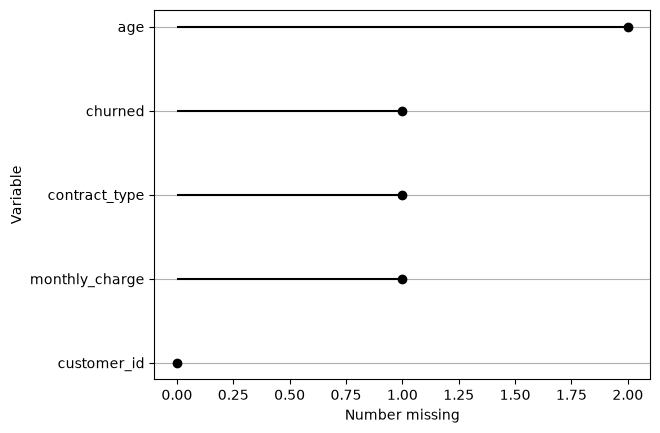

In [14]:
df.missing.missing_variable_plot();

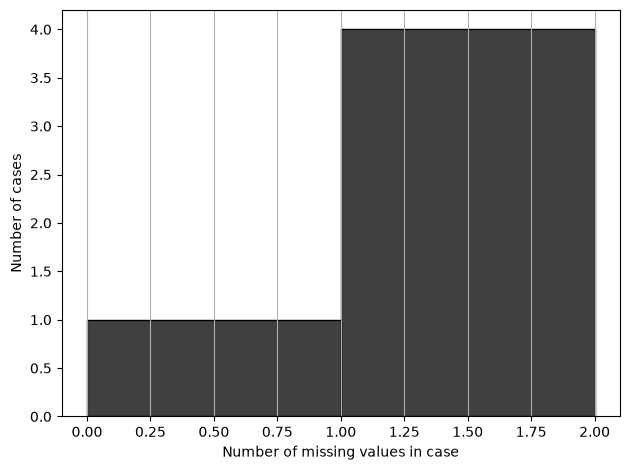

In [15]:
df.missing.missing_case_plot();

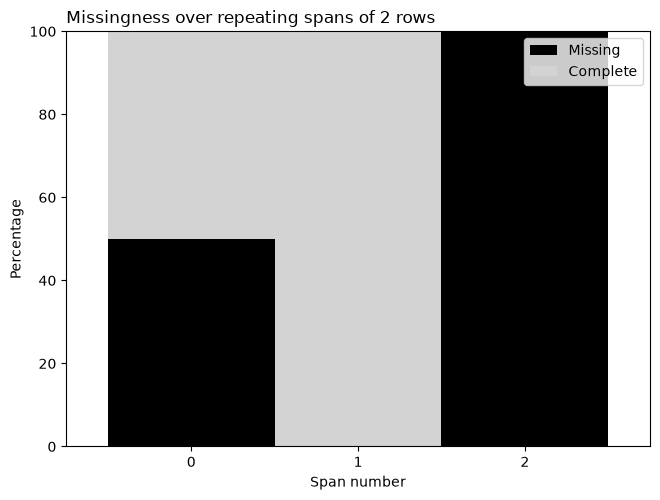

In [16]:
df.missing.missing_variable_span_plot(variable="age", span_every=2);

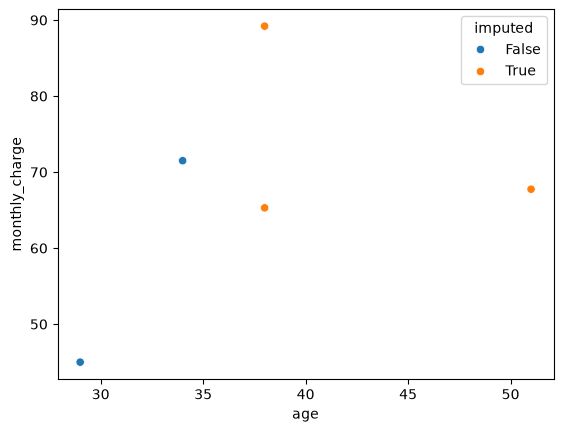

In [17]:
df.missing.scatterplot_imputation_plot(
    x_col="age",
    y_col="monthly_charge",
    impute_strategy="mean",
);